# Systems Thinking VLM — Results Analysis
## Qwen2-VL-7B-Instruct · `vlm_results_qwen_20260227_152809.json`

This notebook provides an extensive analysis of the pipeline output:  
327 participant responses across 10 systems-thinking concepts, scored against Qwen2-VL's visual interpretations.

**Key grounding metrics compared here:**
- `sim_above_concept_scalar` = `similarity_en - concept_sim_en`
- `sim_above_concept_vec` = concept removed from subject embedding only
- `sim_above_concept_vec_both` = concept removed from both subject and VLM embeddings

**Sections:**
1. Import Libraries & Load Data  
2. Data Cleaning & Preprocessing  
3. Similarity Score Distributions  
4. Similarity Metrics Comparison (statistical tests)  
5. Per-Concept Performance  
6. BERTScore Analysis  
7. Answer Length vs. Similarity  
8. Fallback & Cache Statistics  
9. Top / Bottom Performing Responses  
10. Similarity Above Concept Baseline  
11. Cross-Metric Correlation Heatmap  
12. Summary Statistics Table  
13. Per-Subject Score vs. Questionnaire Performance  


## 1 · Import Libraries and Load Data

In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})

RESULTS_FILE = "results/vlm_results_qwen_20260227_152809.json"

with open(RESULTS_FILE) as f:
    raw = json.load(f)["results"]

# Keep only fully-populated records (skip entries that only have a timestamp)
REQUIRED = ["stem", "similarity", "similarity_en", "bertscore_f1", "concept_sim_en",
            "sim_above_concept_scalar", "sim_above_concept_vec", "sim_above_concept_vec_both", "subject_word_count"]
full_records = [r for r in raw if all(k in r and r[k] != "" for k in REQUIRED)]

df_raw = pd.DataFrame(full_records)
print(f"Total records in file : {len(raw)}")
print(f"Fully populated records: {len(df_raw)}")
df_raw.head(2)


Total records in file : 327
Fully populated records: 327


,stem,question_num,answer_num,participant_num,image_path,question_he,question_en,concept_text,full_prompt,vlm_raw_answer_en,...,bertscore_f1,vlm_model,embed_model,he_en_model,en_he_model,device,timestamp,sim_above_concept_scalar,sim_above_concept_vec,sim_above_concept_vec_both
0,10_1_11,10,1,11,dataset/images/10_1.png,"הסבירו מדוע בחרתם בתמונה זו כמשקפת את המשפט "" ...",Explain why you chose this image as reflecting...,Change is made,You are a systems thinking expert. Look at the...,The image shows six individuals of varying age...,...,0.8470,Qwen/Qwen2-VL-7B-Instruct,sentence-transformers/paraphrase-multilingual-...,Helsinki-NLP/opus-mt-tc-big-he-en,Helsinki-NLP/opus-mt-en-he,cuda,2026-02-27T15:31:31,-0.4708,0.1495,0.1580
1,10_1_14,10,1,14,dataset/images/10_1.png,"הסבירו מדוע בחרתם בתמונה זו כמשקפת את המשפט "" ...",Explain why you chose this image as reflecting...,Change is made,You are a systems thinking expert. Look at the...,The image shows six individuals of varying age...,...,0.8287,Qwen/Qwen2-VL-7B-Instruct,sentence-transformers/paraphrase-multilingual-...,Helsinki-NLP/opus-mt-tc-big-he-en,Helsinki-NLP/opus-mt-en-he,cuda,2026-02-27T15:32:22,0.1476,0.4120,0.4353


## 2 · Data Cleaning and Preprocessing

In [2]:
NUMERIC = [
    "similarity", "similarity_percent",
    "similarity_en", "similarity_en_percent",
    "similarity_labse_he", "similarity_labse_he_percent",
    "concept_sim_en", "sim_above_concept_scalar", "sim_above_concept_vec", "sim_above_concept_vec_both",
    "bertscore_precision", "bertscore_recall", "bertscore_f1",
    "subject_word_count",
]

df = df_raw.copy()
df[NUMERIC] = df[NUMERIC].apply(pd.to_numeric, errors="coerce")
df.dropna(subset=NUMERIC, inplace=True)

# Parse timestamps
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.sort_values("timestamp", inplace=True)
df.reset_index(drop=True, inplace=True)

# Derived columns
df["vlm_answer_word_count"] = df["vlm_answer_en"].str.split().str.len()
df["response_latency_s"] = df["timestamp"].diff().dt.total_seconds()
df["question_num"] = df["question_num"].astype(str)
df["answer_num"]   = df["answer_num"].astype(str)

# Short concept label for plots
concept_map = {c: f"Q{q}" for q, c in df.groupby("question_num")["concept_text"].first().items()}
df["question_label"] = df["question_num"].map(lambda q: f"Q{q}: " + df.loc[df.question_num==q,"concept_text"].iloc[0][:30])

print(f"Clean DataFrame: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nNumeric summary:")
df[NUMERIC].describe().round(3)


Clean DataFrame: 327 rows × 41 columns

Numeric summary:


,similarity,similarity_percent,similarity_en,similarity_en_percent,similarity_labse_he,similarity_labse_he_percent,concept_sim_en,sim_above_concept_scalar,sim_above_concept_vec,sim_above_concept_vec_both,bertscore_precision,bertscore_recall,bertscore_f1,subject_word_count
count,327.000,327.000,327.000,327.000,327.000,327.000,327.000,327.000,327.000,327.000,327.000,327.000,327.000,327.000
mean,0.535,53.522,0.494,49.390,0.372,37.246,0.419,0.075,0.350,0.388,0.825,0.867,0.845,12.379
std,0.136,13.640,0.166,16.567,0.129,12.857,0.170,0.197,0.174,0.191,0.017,0.021,0.016,11.113
min,0.153,15.320,0.015,1.450,0.016,1.630,0.016,-0.516,0.006,0.007,0.773,0.809,0.791,1.000
25%,0.448,44.835,0.385,38.450,0.285,28.540,0.294,-0.049,0.216,0.239,0.813,0.851,0.834,6.000
50%,0.543,54.270,0.505,50.520,0.369,36.940,0.412,0.059,0.354,0.394,0.823,0.869,0.846,9.000
75%,0.627,62.735,0.624,62.350,0.453,45.275,0.547,0.214,0.491,0.540,0.835,0.879,0.856,15.000
max,0.898,89.750,0.828,82.770,0.809,80.940,0.826,0.537,0.765,0.799,0.895,0.943,0.889,75.000


## 3 · Similarity Score Distribution Analysis

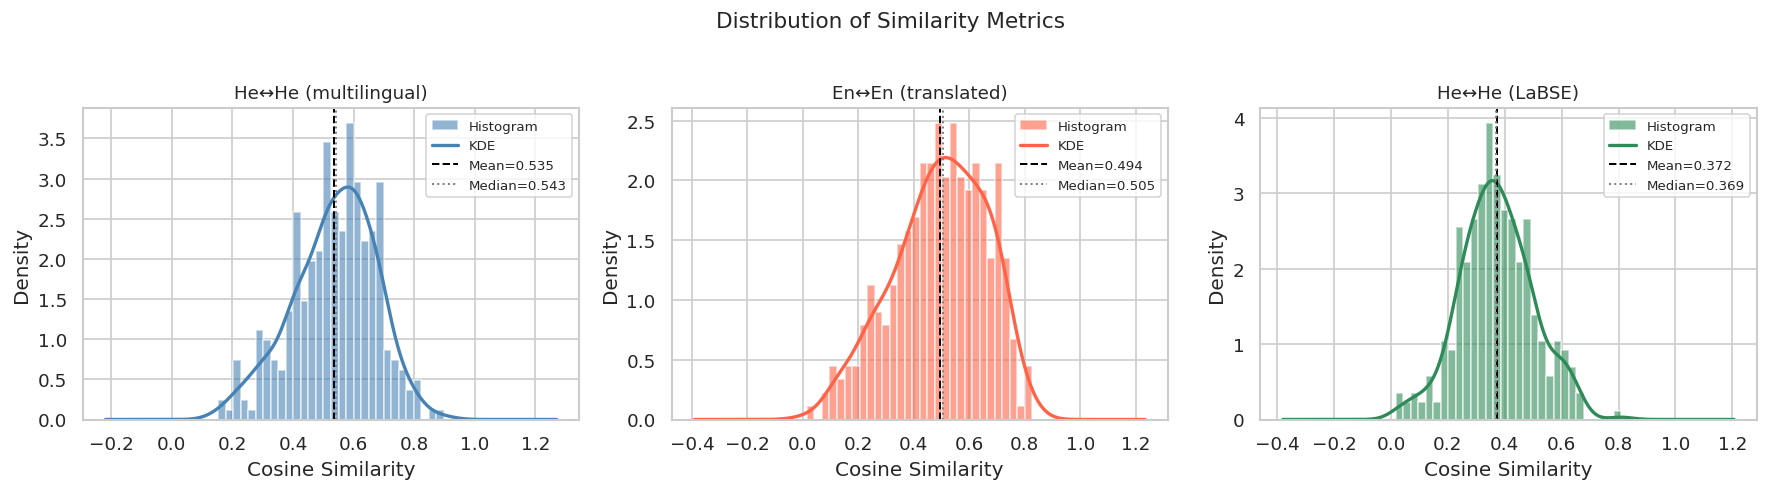

,mean,std,min,50%,max,IQR
He↔He (multilingual),0.5352,0.1364,0.1532,0.5427,0.8975,NaN
En↔En (translated),0.4939,0.1657,0.0145,0.5052,0.8277,NaN
He↔He (LaBSE),0.3725,0.1286,0.0163,0.3694,0.8094,NaN


In [46]:
sim_cols  = ["similarity", "similarity_en", "similarity_labse_he"]
sim_labels = ["He↔He (multilingual)", "En↔En (translated)", "He↔He (LaBSE)"]
colors     = ["steelblue", "tomato", "seagreen"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, col, label, color in zip(axes, sim_cols, sim_labels, colors):
    data = df[col].dropna()
    ax.hist(data, bins=30, color=color, alpha=0.6, density=True, label="Histogram")
    data.plot.kde(ax=ax, color=color, linewidth=2, label="KDE")
    ax.axvline(data.mean(), color="black", linestyle="--", linewidth=1.2,
               label=f"Mean={data.mean():.3f}")
    ax.axvline(data.median(), color="gray", linestyle=":", linewidth=1.2,
               label=f"Median={data.median():.3f}")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Cosine Similarity")
    ax.legend(fontsize=8)

plt.suptitle("Distribution of Similarity Metrics", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Descriptive statistics table
desc = df[sim_cols].describe().T.rename(columns=str)
desc.index = sim_labels
desc["IQR"] = df[sim_cols].quantile(0.75) - df[sim_cols].quantile(0.25)
desc[["mean","std","min","50%","max","IQR"]].round(4)


## 4 · Similarity Metrics Comparison (Statistical Tests)

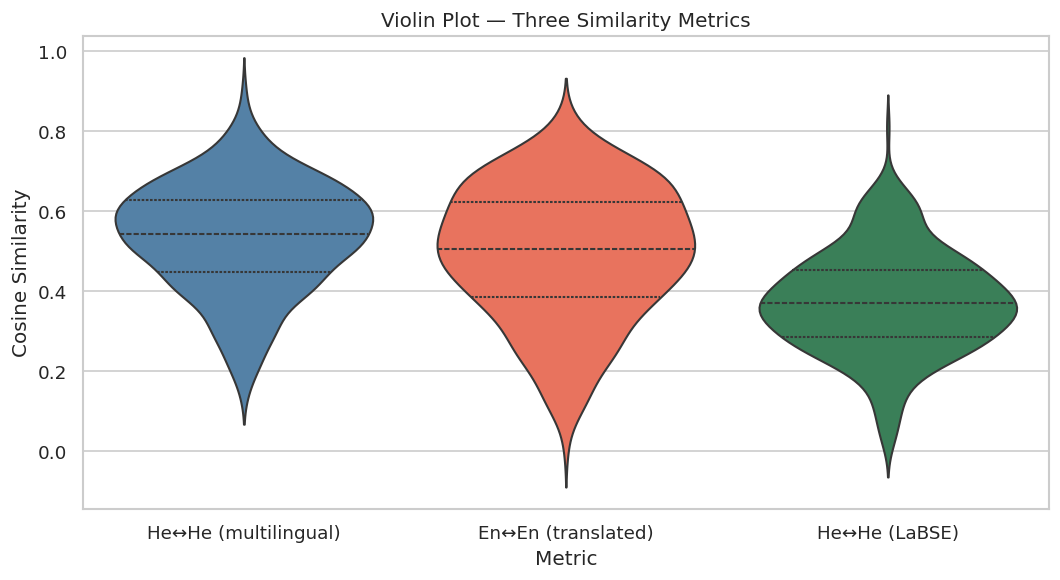

,Metric A,Metric B,mean A,mean B,t-statistic,p-value,Significant (α=0.05)
0,He↔He (multilingual),En↔En (translated),0.5352,0.4939,6.4255,4.66e-10,✓
1,He↔He (multilingual),He↔He (LaBSE),0.5352,0.3725,25.4621,1.69e-79,✓
2,En↔En (translated),He↔He (LaBSE),0.4939,0.3725,15.7034,8.94e-42,✓


In [47]:
fig, ax = plt.subplots(figsize=(9, 5))
violin_data = pd.melt(df[sim_cols], var_name="Metric", value_name="Score")
violin_data["Metric"] = violin_data["Metric"].map(dict(zip(sim_cols, sim_labels)))
sns.violinplot(data=violin_data, x="Metric", y="Score",
               palette=colors, inner="quartile", ax=ax)
ax.set_title("Violin Plot — Three Similarity Metrics", fontsize=12)
ax.set_ylabel("Cosine Similarity")
plt.tight_layout()
plt.show()

# Paired t-tests between every pair of metrics
pairs = [(0,1),(0,2),(1,2)]
rows = []
for i, j in pairs:
    a, b = df[sim_cols[i]].dropna(), df[sim_cols[j]].dropna()
    t, p = stats.ttest_rel(a[:min(len(a),len(b))], b[:min(len(a),len(b))])
    rows.append({
        "Metric A": sim_labels[i], "Metric B": sim_labels[j],
        "mean A": round(a.mean(),4), "mean B": round(b.mean(),4),
        "t-statistic": round(t,4), "p-value": f"{p:.2e}",
        "Significant (α=0.05)": "✓" if p < 0.05 else "✗"
    })
pd.DataFrame(rows)


## 5 · Per-Concept Performance Analysis

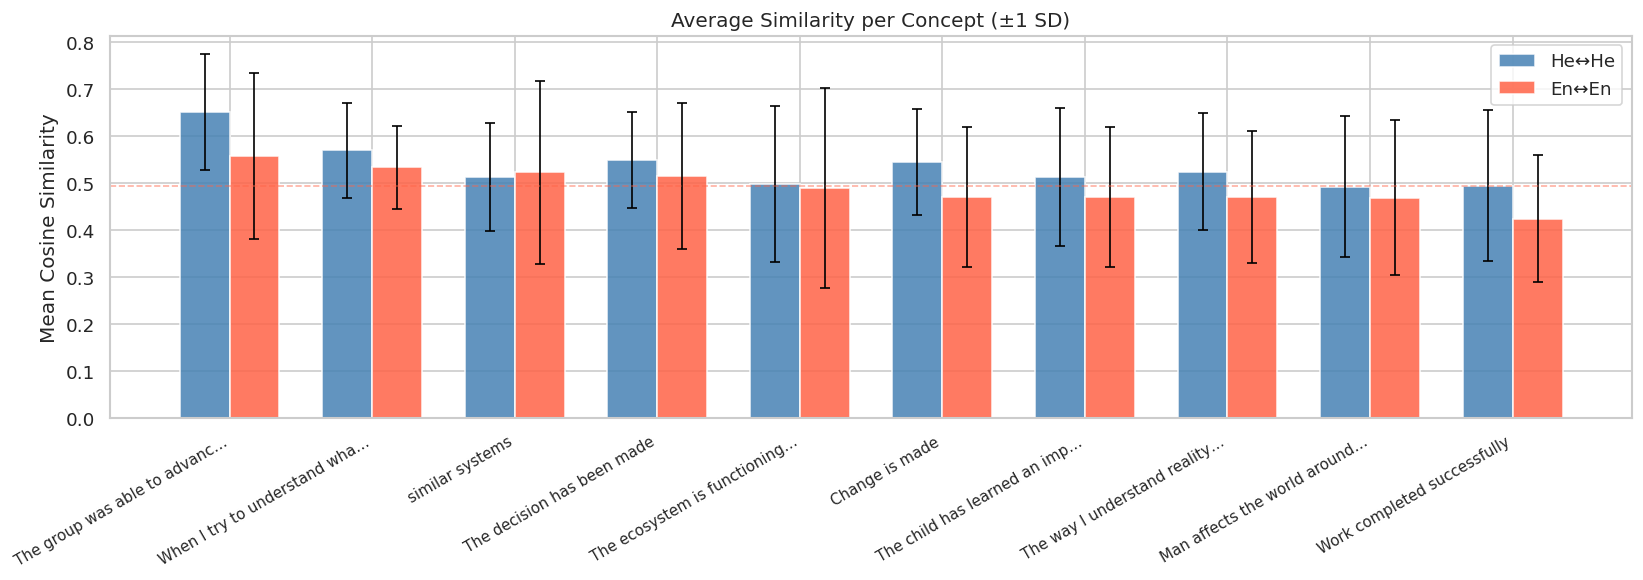

Best concept  (sim_en_mean): The group was able to advance towards the goal
Worst concept (sim_en_mean): Work completed successfully


,sim_mean,sim_median,sim_std,sim_en_mean,sim_en_median,sim_en_std
concept_text,,,,,,
The group was able to advance towards the goal,0.6510,0.6606,0.1236,0.5582,0.6087,0.1776
When I try to understand what is happening sometimes I see things differently,0.5700,0.5197,0.1018,0.5343,0.5249,0.0881
similar systems,0.5125,0.5250,0.1149,0.5235,0.5529,0.1952
The decision has been made,0.5503,0.5637,0.1020,0.5159,0.5377,0.1557
The ecosystem is functioning well,0.4977,0.5427,0.1664,0.4901,0.5341,0.2135
Change is made,0.5460,0.5356,0.1132,0.4713,0.4752,0.1487
The child has learned an important lesson,0.5125,0.5785,0.1468,0.4709,0.5052,0.1490
The way I understand reality affects what I see,0.5245,0.5317,0.1250,0.4698,0.4896,0.1405
Man affects the world around him,0.4928,0.4897,0.1499,0.4689,0.4633,0.1653


In [48]:
concept_stats = (
    df.groupby("concept_text")[["similarity", "similarity_en"]]
    .agg(["mean", "median", "std"])
    .round(4)
)
concept_stats.columns = ["sim_mean","sim_median","sim_std",
                          "sim_en_mean","sim_en_median","sim_en_std"]
concept_stats = concept_stats.sort_values("sim_en_mean", ascending=False)

# Plot grouped bar chart
x = np.arange(len(concept_stats))
w = 0.35
fig, ax = plt.subplots(figsize=(14, 5))
bars1 = ax.bar(x - w/2, concept_stats["sim_mean"],    w, label="He↔He",    color="steelblue", alpha=0.85)
bars2 = ax.bar(x + w/2, concept_stats["sim_en_mean"], w, label="En↔En",    color="tomato",    alpha=0.85)
ax.errorbar(x - w/2, concept_stats["sim_mean"],    yerr=concept_stats["sim_std"],    fmt="none", color="black", capsize=3, linewidth=1)
ax.errorbar(x + w/2, concept_stats["sim_en_mean"], yerr=concept_stats["sim_en_std"], fmt="none", color="black", capsize=3, linewidth=1)
ax.set_xticks(x)
short_labels = [c[:28] + "…" if len(c) > 28 else c for c in concept_stats.index]
ax.set_xticklabels(short_labels, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Mean Cosine Similarity")
ax.set_title("Average Similarity per Concept (±1 SD)", fontsize=12)
ax.legend()
ax.axhline(df["similarity_en"].mean(), color="tomato", linestyle="--", linewidth=1, alpha=0.5, label="Global mean (En)")
plt.tight_layout()
plt.show()

print("Best concept  (sim_en_mean):", concept_stats["sim_en_mean"].idxmax())
print("Worst concept (sim_en_mean):", concept_stats["sim_en_mean"].idxmin())
concept_stats


## 6 · BERTScore Analysis

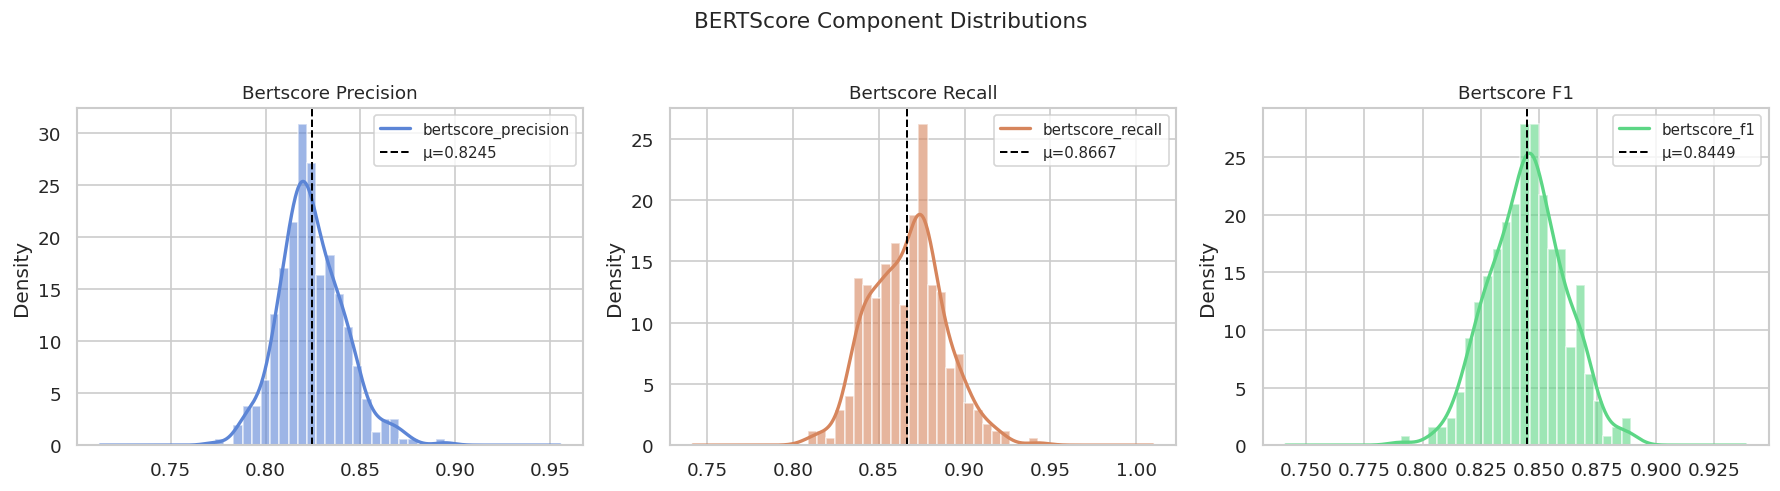

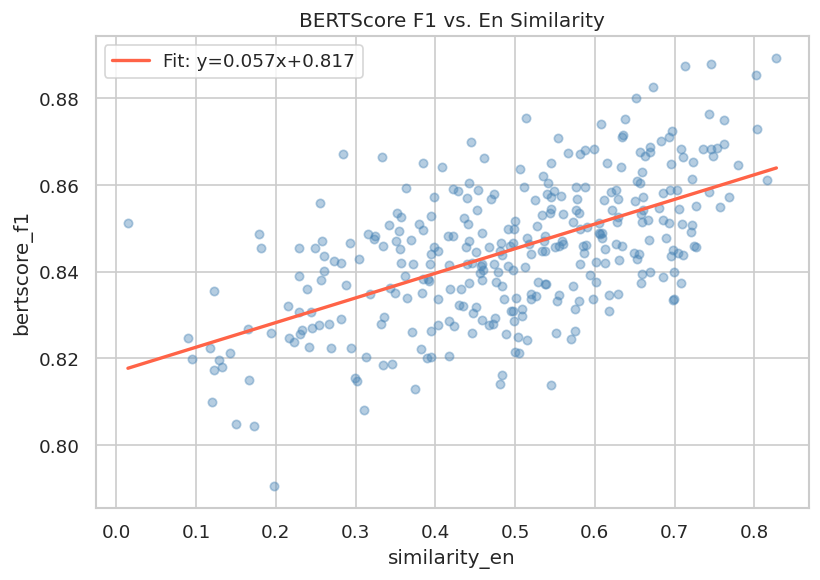

,BERTScore,Similarity,Pearson r,Pearson p,Spearman ρ,Spearman p
0,bertscore_precision,similarity,0.5211,3.72e-24,0.5019,2.87e-22
1,bertscore_precision,similarity_en,0.6165,1.26e-35,0.6167,1.22e-35
2,bertscore_recall,similarity,0.3126,7.63e-09,0.2782,3.18e-07
3,bertscore_recall,similarity_en,0.3772,1.71e-12,0.3627,1.33e-11
4,bertscore_f1,similarity,0.4893,4.31e-21,0.4372,1.07e-16
5,bertscore_f1,similarity_en,0.5841,2.69e-31,0.5568,5.13e-28


In [49]:
bs_cols   = ["bertscore_precision", "bertscore_recall", "bertscore_f1"]
bs_colors = ["#5C85D6", "#D6855C", "#5CD685"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, col, color in zip(axes, bs_cols, bs_colors):
    data = df[col].dropna()
    ax.hist(data, bins=25, color=color, alpha=0.6, density=True)
    data.plot.kde(ax=ax, color=color, linewidth=2)
    ax.axvline(data.mean(), color="black", linestyle="--", linewidth=1.2, label=f"μ={data.mean():.4f}")
    ax.set_title(col.replace("bertscore_","BERTScore ").title(), fontsize=11)
    ax.legend(fontsize=9)
plt.suptitle("BERTScore Component Distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Correlations with similarity metrics
corr_rows = []
for bs in bs_cols:
    for sim in ["similarity", "similarity_en"]:
        r_p, p_p = stats.pearsonr(df[bs], df[sim])
        r_s, p_s = stats.spearmanr(df[bs], df[sim])
        corr_rows.append({"BERTScore": bs, "Similarity": sim,
                           "Pearson r": round(r_p,4), "Pearson p": f"{p_p:.2e}",
                           "Spearman ρ": round(r_s,4), "Spearman p": f"{p_s:.2e}"})
corr_df = pd.DataFrame(corr_rows)

# Scatter: bertscore_f1 vs similarity_en
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["similarity_en"], df["bertscore_f1"], alpha=0.4, s=25, color="steelblue")
m, b = np.polyfit(df["similarity_en"], df["bertscore_f1"], 1)
x_line = np.linspace(df["similarity_en"].min(), df["similarity_en"].max(), 100)
ax.plot(x_line, m*x_line + b, color="tomato", linewidth=2, label=f"Fit: y={m:.3f}x+{b:.3f}")
ax.set_xlabel("similarity_en")
ax.set_ylabel("bertscore_f1")
ax.set_title("BERTScore F1 vs. En Similarity", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

corr_df


## 7 · Answer Length vs. Similarity

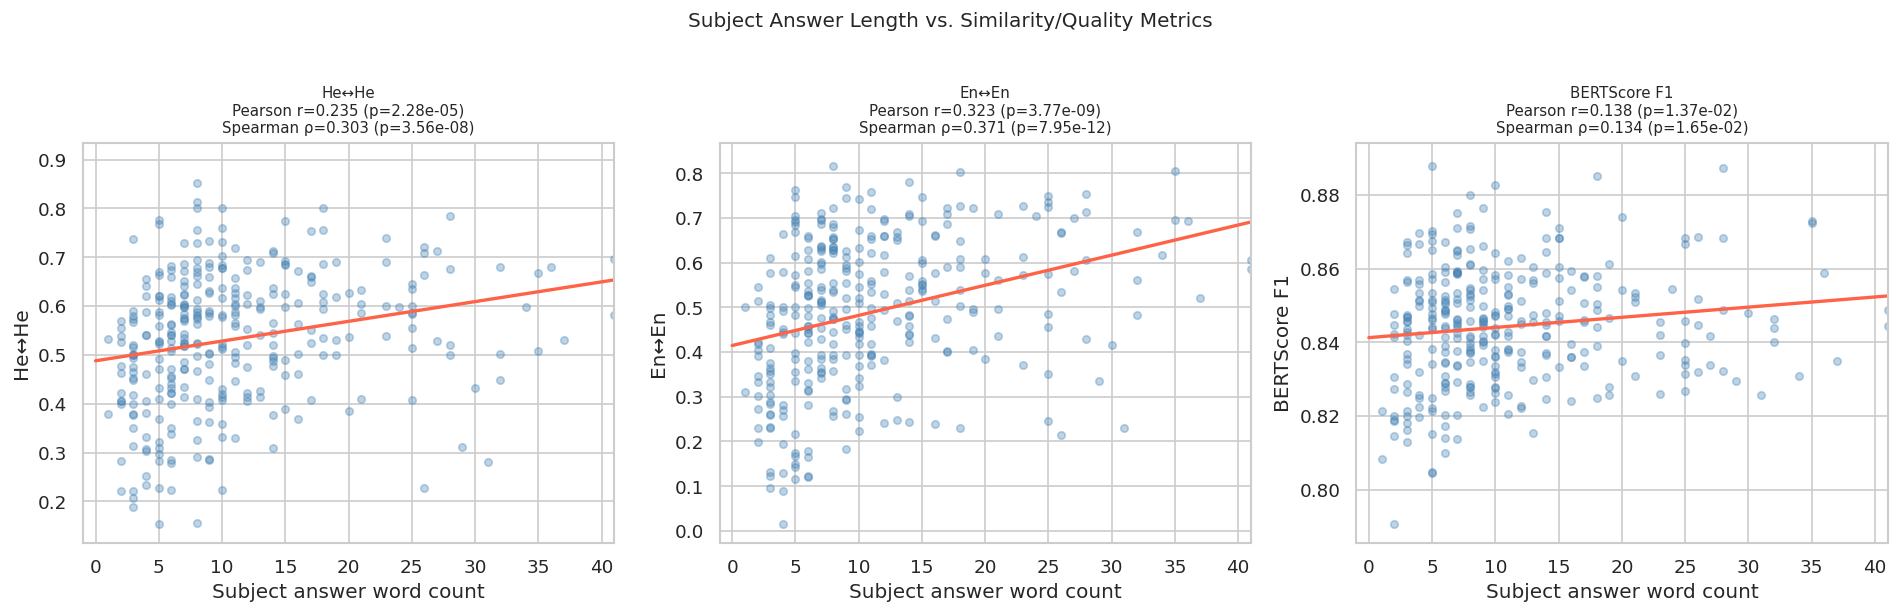

,similarity,similarity_en,sim_above_concept_vec,sim_above_concept_vec_both,sim_above_concept_scalar
length_bracket,,,,,
short (≤5),0.4609,0.3870,0.2664,0.2942,0.0441
medium (6-20),0.5519,0.5125,0.3606,0.4009,0.0760
long (>20),0.5818,0.5833,0.4349,0.4833,0.1209


In [7]:
targets = [("similarity", "He↔He"), ("similarity_en", "En↔En"), ("bertscore_f1", "BERTScore F1")]
wc = df["subject_word_count"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (col, label) in zip(axes, targets):
    y = df[col]
    ax.scatter(wc, y, alpha=0.35, s=20, color="steelblue")
    # Cap long outliers for readability
    xlim = wc.quantile(0.97)
    ax.set_xlim(-1, xlim)
    mask = wc <= xlim
    m, b = np.polyfit(wc[mask], y[mask], 1)
    x_line = np.linspace(0, xlim, 100)
    ax.plot(x_line, m*x_line + b, color="tomato", linewidth=2)
    r_p, p_p = stats.pearsonr(wc[mask], y[mask])
    r_s, p_s = stats.spearmanr(wc[mask], y[mask])
    ax.set_xlabel("Subject answer word count")
    ax.set_ylabel(label)
    ax.set_title(f"{label}\nPearson r={r_p:.3f} (p={p_p:.2e})\nSpearman ρ={r_s:.3f} (p={p_s:.2e})",
                 fontsize=9)

plt.suptitle("Subject Answer Length vs. Similarity/Quality Metrics", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Bracket analysis: short (≤5), medium (6–20), long (>20)
df["length_bracket"] = pd.cut(df["subject_word_count"],
                               bins=[0, 5, 20, 9999],
                               labels=["short (≤5)", "medium (6-20)", "long (>20)"])
df.groupby("length_bracket")[[
    "similarity", "similarity_en",
    "sim_above_concept_vec", "sim_above_concept_vec_both", "sim_above_concept_scalar"
]].mean().round(4)


## 8 · Fallback and Cache Usage Statistics

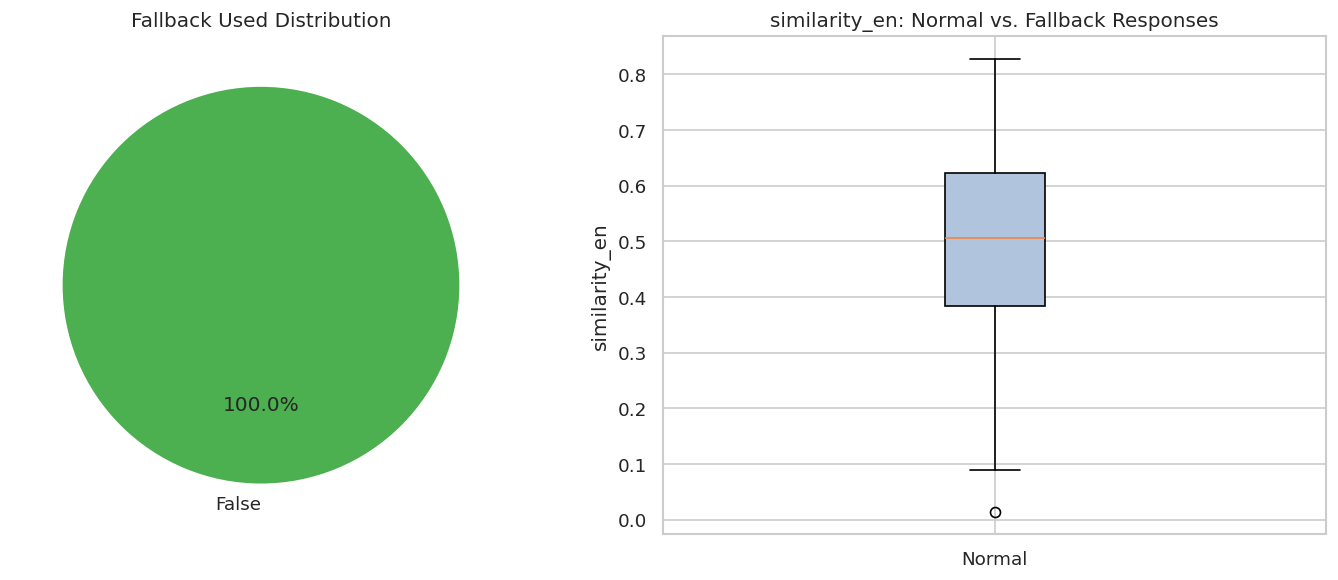


Fallback vs Normal — metric means & std:

              similarity         similarity_en         sim_above_concept_vec         sim_above_concept_vec_both         sim_above_concept_scalar         bertscore_f1        
                    mean     std          mean     std                  mean     std                       mean     std                     mean     std         mean     std
used_fallback                                                                                                                                                                
False             0.5352  0.1364        0.4939  0.1657                0.3498  0.1743                     0.3885  0.1911                   0.0753  0.1971       0.8449  0.0161

No fallback samples found — all responses are normal VLM outputs.


In [8]:
# ----- Fallback usage -----
fallback_counts = df["used_fallback"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie: fallback vs real VLM answer
axes[0].pie(fallback_counts.values, labels=[str(k) for k in fallback_counts.index],
            autopct="%1.1f%%", startangle=90,
            colors=["#4CAF50", "#F44336"] if (False in fallback_counts.index) else ["#F44336", "#4CAF50"])
axes[0].set_title("Fallback Used Distribution")

# Similarity difference: fallback vs non-fallback
groups = [df.loc[df["used_fallback"] == v, "similarity_en"].dropna().values
          for v in [False, True] if v in df["used_fallback"].values]
group_labels = [lbl for lbl, v in [("Normal", False), ("Fallback", True)]
                if v in df["used_fallback"].values]
axes[1].boxplot(groups, tick_labels=group_labels, patch_artist=True,
                boxprops=dict(facecolor="lightsteelblue"))
axes[1].set_ylabel("similarity_en")
axes[1].set_title("similarity_en: Normal vs. Fallback Responses")

plt.tight_layout()
plt.show()

ft = df.groupby("used_fallback")[[
    "similarity", "similarity_en",
    "sim_above_concept_vec", "sim_above_concept_vec_both", "sim_above_concept_scalar",
    "bertscore_f1"
]].agg(["mean", "std"]).round(4)
print("\nFallback vs Normal — metric means & std:\n")
print(ft.to_string())

# Statistical test (Mann-Whitney)
if all(v in df["used_fallback"].values for v in [True, False]):
    from scipy.stats import mannwhitneyu
    for col in ["similarity_en", "sim_above_concept_vec", "sim_above_concept_vec_both", "bertscore_f1"]:
        a = df.loc[df["used_fallback"] == False, col].dropna()
        b = df.loc[df["used_fallback"] == True,  col].dropna()
        if len(b) > 0:
            stat, p = mannwhitneyu(a, b, alternative="two-sided")
            print(f"  {col}: Mann-Whitney U={stat:.0f}, p={p:.4f} (n_normal={len(a)}, n_fallback={len(b)})")
else:
    print("\nNo fallback samples found — all responses are normal VLM outputs.")


## 9 · Top and Bottom Performing Responses

In [9]:
display_cols = ["question_label", "subject_answer_he", "vlm_answer_en",
                "similarity_en", "sim_above_concept_vec", "sim_above_concept_vec_both", "sim_above_concept_scalar", "subject_word_count"]

top10 = df.nlargest(10, "similarity_en")[display_cols].copy()
bot10 = df.nsmallest(10, "similarity_en")[display_cols].copy()

for col in ["similarity_en", "sim_above_concept_vec", "sim_above_concept_vec_both", "sim_above_concept_scalar"]:
    top10[col] = top10[col].round(3)
    bot10[col] = bot10[col].round(3)

# Truncate long text for display
def trunc(s, n=80):
    return s[:n] + "…" if isinstance(s, str) and len(s) > n else s

for col in ["subject_answer_he", "vlm_answer_en"]:
    top10[col] = top10[col].apply(trunc)
    bot10[col] = bot10[col].apply(trunc)

print("═══ TOP 10 responses (by similarity_en) ═══")
display(top10.reset_index(drop=True).style
        .background_gradient(subset=["similarity_en"], cmap="Greens")
        .background_gradient(subset=["sim_above_concept_vec"], cmap="RdYlGn")
        .background_gradient(subset=["sim_above_concept_vec_both"], cmap="Purples")
        .background_gradient(subset=["sim_above_concept_scalar"], cmap="PuOr")
        .set_properties(**{"font-size":"9pt"}))

print("\n═══ BOTTOM 10 responses (by similarity_en) ═══")
display(bot10.reset_index(drop=True).style
        .background_gradient(subset=["similarity_en"], cmap="Reds_r")
        .background_gradient(subset=["sim_above_concept_vec"], cmap="RdYlGn")
        .background_gradient(subset=["sim_above_concept_vec_both"], cmap="Purples")
        .background_gradient(subset=["sim_above_concept_scalar"], cmap="PuOr")
        .set_properties(**{"font-size":"9pt"}))


═══ TOP 10 responses (by similarity_en) ═══


,question_label,subject_answer_he,vlm_answer_en,similarity_en,sim_above_concept_vec,sim_above_concept_vec_both,sim_above_concept_scalar,subject_word_count
0,Q6: The group was able to advance,"חרתי בתמונה של צוות החותרים בסירה (אפשרות 2), משום שהיא ממחישה באופן ברור התקדמו…",This image reflects the sentence by showing a team of rowers working together on…,0.828000,0.699000,0.781000,0.344000,59
1,Q10: Change is made,"תהליך של הפרח בצמיחה, ושינוי נעשה לאורך תקופה","The image captures four stages of flower development, from bud to wilted bloom. …",0.816000,0.765000,0.799000,0.416000,8
2,Q5: similar systems,התמונה מראה בצורה ברורה את ההקבלה בין מבנה חברתי ותפקודי של דבורים בכוורת לבין מ…,"The image juxtaposes two scenes that share structural similarities, symbolizing …",0.804000,0.672000,0.750000,0.307000,35
3,Q6: The group was able to advance,בחרתי בתמונה של קבוצת האנשים בסירת המשוטים משום שהם מתקדמים לעבר המטרה יחד בתור …,This image reflects the sentence by showing a team of rowers working together on…,0.802000,0.668000,0.746000,0.295000,18
4,Q4: The ecosystem is functioning w,"הדבורה מאביקה את הפרח, זה קשר הדדי בין יצורים חיים שמאפשר המשכיות למערכת האקולוג…","This image shows a bee collecting nectar from flowers, which indicates that ther…",0.780000,0.613000,0.705000,0.260000,14
5,Q9: Man affects the world around h,היד שמחזיקה את העולם שאנו הם שמשפיעים על הסביבה,"The image features an icon of hands holding up a globe, symbolizing human intera…",0.768000,0.585000,0.679000,0.216000,9
6,Q4: The ecosystem is functioning w,תפקיד הדבורה הוא לשתות צוף,"This image shows a bee collecting nectar from flowers, which indicates that ther…",0.762000,0.641000,0.736000,0.451000,5
7,Q5: similar systems,ממחישה בצורה ברורה את הדמיון בין מערכות שונות – מערכת טבעית (כוורת דבורים) ומערכ…,"The image juxtaposes two scenes that share structural similarities, symbolizing …",0.762000,0.624000,0.696000,0.104000,50
8,Q6: The group was able to advance,בקבוצת חותרים יש אלמנט מרכזי של סנכרון. לכן זו משימה קבוצתית,This image reflects the sentence by showing a team of rowers working together on…,0.757000,0.635000,0.710000,0.376000,11
9,Q2: The decision has been made,"בחרתי בתמונה בה כל חברי הצוות מחזיקים ידיים או מוחאים כפיים, מהסיבה שפעולות אלו …","In the image, I observed that people around an office table have their hands tog…",0.753000,0.663000,0.711000,0.343000,28



═══ BOTTOM 10 responses (by similarity_en) ═══


,question_label,subject_answer_he,vlm_answer_en,similarity_en,sim_above_concept_vec,sim_above_concept_vec_both,sim_above_concept_scalar,subject_word_count
0,Q7: The way I understand reality a,ככה זה הכי טוב,"In the image, there is an individual standing before a mirror that reflects thei…",0.015000,0.006000,0.007000,-0.002000,4
1,Q2: The decision has been made,התמונה היחידה שמייצגת סופיות,"In the image, I observed that people around an office table have their hands tog…",0.090000,0.049000,0.052000,-0.024000,4
2,Q4: The ecosystem is functioning w,אין הרבה לפרט,"This image shows a bee collecting nectar from flowers, which indicates that ther…",0.095000,0.038000,0.044000,-0.020000,3
3,Q4: The ecosystem is functioning w,זה מה שהרגיש לי לנכון,"This image shows two individuals working on installing solar panels, which indic…",0.117000,0.058000,0.062000,-0.059000,5
4,Q9: Man affects the world around h,כן באיתקה שלו וגם הידע שלו,"The image shows individuals engaging in community service, specifically planting…",0.119000,0.018000,0.020000,-0.172000,6
5,Q10: Change is made,מורוד מת עד לורוד חי וזוהר,"The image captures four stages of flower development, from bud to wilted bloom. …",0.122000,0.088000,0.092000,0.002000,6
6,Q4: The ecosystem is functioning w,נראה הכי אמיתי,"This image shows two individuals working on installing solar panels, which indic…",0.123000,0.077000,0.082000,-0.014000,3
7,Q2: The decision has been made,נראה הכי מטעים לסיטואציה,"In the image, I observed that people around an office table have their hands tog…",0.129000,0.039000,0.042000,-0.122000,4
8,Q5: similar systems,אין סיבה ספציפית,"The image juxtaposes two scenes that share structural similarities, symbolizing …",0.133000,0.072000,0.080000,-0.007000,3
9,Q7: The way I understand reality a,לא בוחר בשום תמונה כאן.,"In the image, there is an individual standing before a mirror that reflects thei…",0.143000,0.071000,0.085000,0.010000,5


## 9b · Top and Bottom Performing Responses by Concept-Adjusted Metrics

We compare three concept-adjusted signals:

- `sim_above_concept_scalar = similarity_en − concept_sim_en`
- `sim_above_concept_vec`: remove concept direction from the **subject** embedding, then compare to VLM
- `sim_above_concept_vec_both`: remove concept direction from **both subject and VLM** embeddings, then compare

Where:
- **`similarity_en`** — cosine similarity between the *subject's* answer and the *VLM's* visual description (both translated to English)
- **`concept_sim_en`** — cosine similarity between the *subject's* answer and the bare concept phrase (e.g. "feedback loop")

These tables rank responses by how much a subject's language reflects image-specific content beyond simply echoing the concept.

> **Caveat:** If VLM answers themselves contain concept-like generic wording, all concept-adjusted metrics can still be optimistic upper bounds on true visual grounding.


In [10]:
display_cols_sac = [
    "question_label", "subject_answer_he", "vlm_answer_en",
    "sim_above_concept_vec", "sim_above_concept_vec_both", "sim_above_concept_scalar",
    "similarity_en", "concept_sim_en", "subject_word_count",
]

top10_sac = df.nlargest(10, "sim_above_concept_vec_both")[display_cols_sac].copy()
bot10_sac = df.nsmallest(10, "sim_above_concept_vec_both")[display_cols_sac].copy()

for col in ["sim_above_concept_vec", "sim_above_concept_vec_both", "sim_above_concept_scalar", "similarity_en", "concept_sim_en"]:
    top10_sac[col] = top10_sac[col].round(3)
    bot10_sac[col] = bot10_sac[col].round(3)

for col in ["subject_answer_he", "vlm_answer_en"]:
    top10_sac[col] = top10_sac[col].apply(trunc)
    bot10_sac[col] = bot10_sac[col].apply(trunc)

print("═══ TOP 10 most grounded responses (by sim_above_concept_vec_both) ═══")
display(
    top10_sac.reset_index(drop=True)
    .style
    .background_gradient(subset=["sim_above_concept_vec_both"], cmap="Purples")
    .background_gradient(subset=["sim_above_concept_vec"],      cmap="Greens")
    .background_gradient(subset=["sim_above_concept_scalar"],   cmap="PuOr")
    .background_gradient(subset=["similarity_en"],              cmap="YlGn")
    .background_gradient(subset=["concept_sim_en"],             cmap="Oranges")
    .set_properties(**{"font-size": "9pt"})
    .set_caption("Sorted by sim_above_concept_vec_both ↓  (most de-concepted grounded)")
)

print("\n═══ BOTTOM 10 most concept-echoing responses (by sim_above_concept_vec_both) ═══")
display(
    bot10_sac.reset_index(drop=True)
    .style
    .background_gradient(subset=["sim_above_concept_vec_both"], cmap="Purples_r")
    .background_gradient(subset=["sim_above_concept_vec"],      cmap="Reds_r")
    .background_gradient(subset=["sim_above_concept_scalar"],   cmap="PuOr")
    .background_gradient(subset=["similarity_en"],              cmap="YlOrRd_r")
    .background_gradient(subset=["concept_sim_en"],             cmap="Oranges")
    .set_properties(**{"font-size": "9pt"})
    .set_caption("Sorted by sim_above_concept_vec_both ↑  (least de-concepted grounded)")
)

# Per-concept grounding breakdown table
print("\n═══ Per-concept grounding breakdown ═══")
concept_sac_table = (
    df.groupby("question_label")
    .agg(
        n                      = ("sim_above_concept_vec", "count"),
        mean_SAC_vec           = ("sim_above_concept_vec",      "mean"),
        mean_SAC_vec_both      = ("sim_above_concept_vec_both", "mean"),
        median_SAC_vec_both    = ("sim_above_concept_vec_both", "median"),
        mean_SAC_scalar        = ("sim_above_concept_scalar",   "mean"),
        pct_grounded_scalar    = ("sim_above_concept_scalar",   lambda x: (x > 0).mean() * 100),
        mean_sim_en            = ("similarity_en",              "mean"),
        mean_concept_sim       = ("concept_sim_en",             "mean"),
    )
    .round(3)
    .sort_values("mean_SAC_vec_both", ascending=False)
)
concept_sac_table["pct_grounded_scalar"] = concept_sac_table["pct_grounded_scalar"].round(1)

display(
    concept_sac_table
    .style
    .background_gradient(subset=["mean_SAC_vec_both"],   cmap="Purples")
    .background_gradient(subset=["mean_SAC_vec"],        cmap="RdYlGn")
    .background_gradient(subset=["mean_SAC_scalar"],     cmap="PuOr")
    .background_gradient(subset=["pct_grounded_scalar"], cmap="Blues")
    .background_gradient(subset=["mean_sim_en"],         cmap="YlGn")
    .format({
        "mean_SAC_vec_both":   "{:.3f}",
        "median_SAC_vec_both": "{:.3f}",
        "mean_SAC_vec":        "{:.3f}",
        "mean_SAC_scalar":     "{:.3f}",
        "pct_grounded_scalar": "{:.1f}%",
        "mean_sim_en":         "{:.3f}",
        "mean_concept_sim":    "{:.3f}",
    })
    .set_caption("Concepts sorted by mean sim_above_concept_vec_both (bi-projected grounding)")
)


═══ TOP 10 most grounded responses (by sim_above_concept_vec_both) ═══


,question_label,subject_answer_he,vlm_answer_en,sim_above_concept_vec,sim_above_concept_vec_both,sim_above_concept_scalar,similarity_en,concept_sim_en,subject_word_count
0,Q10: Change is made,"תהליך של הפרח בצמיחה, ושינוי נעשה לאורך תקופה","The image captures four stages of flower development, from bud to wilted bloom. …",0.765000,0.799000,0.416000,0.816000,0.401000,8
1,Q6: The group was able to advance,"חרתי בתמונה של צוות החותרים בסירה (אפשרות 2), משום שהיא ממחישה באופן ברור התקדמו…",This image reflects the sentence by showing a team of rowers working together on…,0.699000,0.781000,0.344000,0.828000,0.484000,59
2,Q4: The ecosystem is functioning w,מראה שהדבורה אוכלת צוף מהפרח,"This image shows a bee collecting nectar from flowers, which indicates that ther…",0.658000,0.756000,0.537000,0.746000,0.209000,5
3,Q5: similar systems,התמונה מראה בצורה ברורה את ההקבלה בין מבנה חברתי ותפקודי של דבורים בכוורת לבין מ…,"The image juxtaposes two scenes that share structural similarities, symbolizing …",0.672000,0.750000,0.307000,0.804000,0.497000,35
4,Q6: The group was able to advance,בחרתי בתמונה של קבוצת האנשים בסירת המשוטים משום שהם מתקדמים לעבר המטרה יחד בתור …,This image reflects the sentence by showing a team of rowers working together on…,0.668000,0.746000,0.295000,0.802000,0.507000,18
5,Q4: The ecosystem is functioning w,תפקיד הדבורה הוא לשתות צוף,"This image shows a bee collecting nectar from flowers, which indicates that ther…",0.641000,0.736000,0.451000,0.762000,0.312000,5
6,Q10: Change is made,הפרח מתחילת צמיחתו עד נבילה ולכן השינוי נעשה באופן משמעותי,"The image captures four stages of flower development, from bud to wilted bloom. …",0.685000,0.715000,0.343000,0.743000,0.400000,10
7,Q4: The ecosystem is functioning w,הדבורה שותה את הצוף ולאחר מכן תפזר את האבקנים וככה יתרבו הצמחים. לכן אקולוגי ביו…,"This image shows a bee collecting nectar from flowers, which indicates that ther…",0.622000,0.715000,0.429000,0.746000,0.317000,15
8,Q6: The group was able to advance,יש משהו חזק בחתירה שכולם מושיים יד ועוזרים לספינה לפעול בפועל,This image reflects the sentence by showing a team of rowers working together on…,0.638000,0.713000,0.500000,0.721000,0.221000,11
9,Q2: The decision has been made,"בחרתי בתמונה בה כל חברי הצוות מחזיקים ידיים או מוחאים כפיים, מהסיבה שפעולות אלו …","In the image, I observed that people around an office table have their hands tog…",0.663000,0.711000,0.343000,0.753000,0.410000,28



═══ BOTTOM 10 most concept-echoing responses (by sim_above_concept_vec_both) ═══


,question_label,subject_answer_he,vlm_answer_en,sim_above_concept_vec,sim_above_concept_vec_both,sim_above_concept_scalar,similarity_en,concept_sim_en,subject_word_count
0,Q7: The way I understand reality a,ככה זה הכי טוב,"In the image, there is an individual standing before a mirror that reflects thei…",0.006000,0.007000,-0.002000,0.015000,0.016000,4
1,Q4: The ecosystem is functioning w,כאשר הכל עובד כרגיל,"This image shows a bee collecting nectar from flowers, which indicates that ther…",0.007000,0.008000,-0.188000,0.195000,0.382000,4
2,Q9: Man affects the world around h,כן באיתקה שלו וגם הידע שלו,"The image shows individuals engaging in community service, specifically planting…",0.018000,0.020000,-0.172000,0.119000,0.292000,6
3,Q7: The way I understand reality a,ניתן לראות שמה שאני מבין זה מה שאני רואה,"In the image, there is an individual standing before a mirror that reflects thei…",0.017000,0.020000,-0.216000,0.294000,0.510000,9
4,Q7: The way I understand reality a,איך שאני תופס את עצמי במציאות זה מי שאני,"In the image, there is an individual standing before a mirror that reflects thei…",0.021000,0.025000,-0.295000,0.393000,0.689000,9
5,Q2: The decision has been made,בכל שאר התמונות נראה כי ההחלטה עוד לא התקבלה,"In the image, I observed that people around an office table have their hands tog…",0.033000,0.035000,-0.239000,0.182000,0.421000,9
6,Q2: The decision has been made,נראה הכי מטעים לסיטואציה,"In the image, I observed that people around an office table have their hands tog…",0.039000,0.042000,-0.122000,0.129000,0.251000,4
7,Q4: The ecosystem is functioning w,אין הרבה לפרט,"This image shows a bee collecting nectar from flowers, which indicates that ther…",0.038000,0.044000,-0.020000,0.095000,0.116000,3
8,Q2: The decision has been made,התמונה היחידה שמייצגת סופיות,"In the image, I observed that people around an office table have their hands tog…",0.049000,0.052000,-0.024000,0.090000,0.114000,4
9,Q1: Work completed successfully,"מבין כל התמונות, בתמונה מספר2 אין דעה לגבי התוצאה. אם התוצאה היא הצלחה, רק תמונה…",The image shows two trucks working together on what appears to be an excavation …,0.047000,0.053000,-0.189000,0.231000,0.420000,31



═══ Per-concept grounding breakdown ═══


,n,mean_SAC_vec,mean_SAC_vec_both,median_SAC_vec_both,mean_SAC_scalar,pct_grounded_scalar,mean_sim_en,mean_concept_sim
question_label,,,,,,,,
Q6: The group was able to advance,31,0.418,0.468,0.493,0.138,77.4%,0.558,0.420
Q5: similar systems,27,0.406,0.448,0.535,0.159,77.8%,0.523,0.365
Q2: The decision has been made,57,0.399,0.431,0.452,0.089,63.2%,0.516,0.427
Q4: The ecosystem is functioning w,39,0.354,0.402,0.419,0.143,66.7%,0.490,0.347
Q10: Change is made,39,0.378,0.397,0.415,0.029,59.0%,0.471,0.442
Q9: Man affects the world around h,36,0.357,0.387,0.384,0.091,63.9%,0.469,0.378
Q8: When I try to understand what,13,0.306,0.363,0.379,0.014,46.2%,0.534,0.520
Q1: Work completed successfully,14,0.307,0.337,0.353,0.072,71.4%,0.425,0.352
Q3: The child has learned an impor,33,0.271,0.317,0.307,0.004,45.5%,0.471,0.467


## 10 · Similarity Above Concept Baseline Analysis

This section compares three concept-adjusted metrics:

- `sim_above_concept_scalar = similarity_en − concept_sim_en`
- `sim_above_concept_vec = cos(subj_perp_concept, vlm)`
- `sim_above_concept_vec_both = cos(subj_perp_concept, vlm_perp_concept)`

Interpretation:
- Higher values indicate stronger alignment with image-specific VLM language after discounting concept-only overlap.
- Negative values are possible for all three metrics in principle; scalar is most likely to go negative in practice.

> **Note:** All three still depend on VLM grounding quality. If VLM output is generic or concept-echoing, these metrics can be optimistic.


In [30]:
# High-grounding percentages for vec_both using median and mean thresholds
vec_both_med_thr = float(df["sim_above_concept_vec_both"].median())
vec_both_avg_thr = float(df["sim_above_concept_vec_both"].mean())

pct_high_vec_both = (df["sim_above_concept_vec_both"] >= vec_both_med_thr).mean() * 100.0
pct_high_vec_both_avg = (df["sim_above_concept_vec_both"] >= vec_both_avg_thr).mean() * 100.0

print(f"SAC high-grounding (vec_both >= median {vec_both_med_thr:.4f}): {pct_high_vec_both:.1f}%")
print(f"SAC high-grounding (vec_both >= mean {vec_both_avg_thr:.4f}): {pct_high_vec_both_avg:.1f}%")

SAC high-grounding (vec_both >= median 0.3944): 50.2%
SAC high-grounding (vec_both >= mean 0.3885): 50.8%


## 11 · Cross-Metric Correlation Heatmap

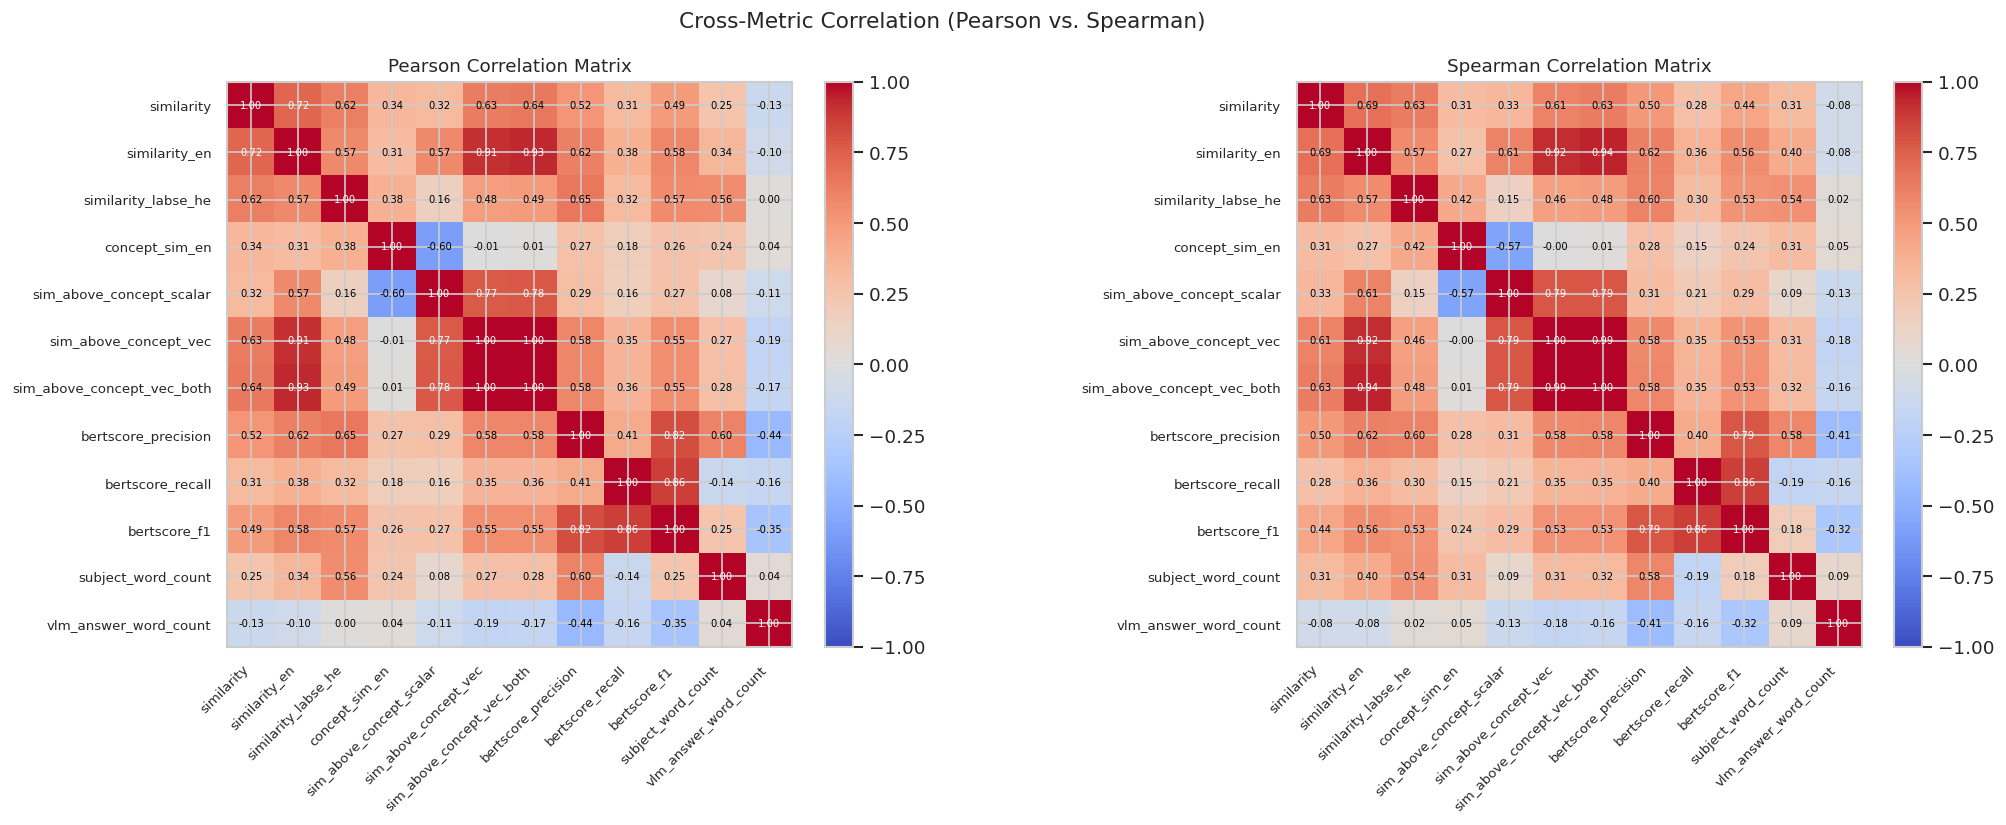

Top 10 Spearman correlations (absolute value):


,Metric A,Metric B,|ρ|
0,sim_above_concept_vec,sim_above_concept_vec_both,0.9950
1,similarity_en,sim_above_concept_vec_both,0.9400
2,similarity_en,sim_above_concept_vec,0.9182
3,bertscore_recall,bertscore_f1,0.8633
4,bertscore_precision,bertscore_f1,0.7890
5,sim_above_concept_scalar,sim_above_concept_vec_both,0.7888
6,sim_above_concept_scalar,sim_above_concept_vec,0.7870
7,similarity,similarity_en,0.6859
8,similarity,sim_above_concept_vec_both,0.6282
9,similarity,similarity_labse_he,0.6276


In [4]:
numeric_cols = [
    "similarity", "similarity_en", "similarity_labse_he",
    "concept_sim_en", "sim_above_concept_scalar", "sim_above_concept_vec", "sim_above_concept_vec_both",
    "bertscore_precision", "bertscore_recall", "bertscore_f1",
    "subject_word_count", "vlm_answer_word_count",
]
# keep only cols that exist in df
numeric_cols = [c for c in numeric_cols if c in df.columns]

corr_p = df[numeric_cols].corr(method="pearson")
corr_s = df[numeric_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, corr, title in zip(axes, [corr_p, corr_s], ["Pearson", "Spearman"]):
    im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(numeric_cols)))
    ax.set_yticks(range(len(numeric_cols)))
    ax.set_xticklabels(numeric_cols, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(numeric_cols, fontsize=8)
    ax.set_title(f"{title} Correlation Matrix", fontsize=11)
    for i in range(len(numeric_cols)):
        for j in range(len(numeric_cols)):
            val = corr.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=6, color="black" if abs(val) < 0.7 else "white")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Cross-Metric Correlation (Pearson vs. Spearman)", fontsize=13)
plt.tight_layout()
plt.show()

# Print strongest off-diagonal Spearman correlations
upper = corr_s.where(np.triu(np.ones(corr_s.shape), k=1).astype(bool))
strongest = (upper.stack()
              .abs()
              .sort_values(ascending=False)
              .head(10)
              .reset_index())
strongest.columns = ["Metric A", "Metric B", "|ρ|"]
strongest["|ρ|"] = strongest["|ρ|"].round(4)
print("Top 10 Spearman correlations (absolute value):")
display(strongest)


## 12 · Summary Statistics Table

In [35]:
vec_both_med_thr = float(df["sim_above_concept_vec_both"].median())
vec_both_avg_thr = float(df["sim_above_concept_vec_both"].mean())

summary = pd.DataFrame({
    "Metric": [
        "SAC_vec_both (remove concept from subject+vlm)",
        f"High-grounding vec_both % (median, >= {vec_both_med_thr:.4f})",
        f"High-grounding vec_both % (mean, >= {vec_both_avg_thr:.4f})",
    ],
    "Value": [
        df["sim_above_concept_vec_both"].mean(),
        (df["sim_above_concept_vec_both"] >= vec_both_med_thr).mean() * 100,
        (df["sim_above_concept_vec_both"] >= vec_both_avg_thr).mean() * 100,
    ]
})
summary


,Metric,Value
0,SAC_vec_both (remove concept from subject+vlm),0.388476
1,"High-grounding vec_both % (median, >= 0.3944)",50.152905
2,"High-grounding vec_both % (mean, >= 0.3885)",50.764526


## 13 · Per-Subject Score vs. Questionnaire Performance

Merge each subject's vec_both SAC score (`mean_SAC_vec_both`) and vec_both high-grounding percentages
(`pct_high_vec_both_median` by median threshold, `pct_high_vec_both_avg` by mean threshold)
with their systems-thinking percentage from `questionnaire_1.csv` (0-100 scale), then test for correlation.

The questionnaire file has rows `Test N` where N is the subject ID (last component of `stem`).  
The pipeline metrics are aggregated per subject across all 10 questions × 2 images they answered.


Questionnaire loaded: 71 subjects  (range 33.3% - 86.4%)
Grounding thresholds: vec_both >= median 0.3944, vec_both >= mean 0.3885
Pipeline subjects: 61  |  Questionnaire subjects: 71
Matched: 61 subjects after join



,subject_id,n,mean_SAC_vec_both,pct_high_vec_both_median,pct_high_vec_both_avg,pct_systems_thinking
1,54,4,0.5656,100.0%,100.0%,86.4%
2,45,1,0.7047,100.0%,100.0%,84.2%
3,27,7,0.3956,57.1%,57.1%,84.0%
4,14,6,0.4146,66.7%,66.7%,83.3%
5,57,5,0.2328,20.0%,20.0%,78.3%
6,68,6,0.2119,0.0%,0.0%,77.8%
7,69,5,0.4211,80.0%,80.0%,76.9%
8,41,7,0.4780,71.4%,71.4%,76.2%
9,62,7,0.3172,42.9%,42.9%,75.0%
10,24,6,0.3638,33.3%,33.3%,75.0%


Correlation with % Systems Thinking (questionnaire_1.csv):


,pipeline_metric,pearson_r,pearson_p,spearman_rho,spearman_p,n
2,pct_high_vec_both_avg,0.3441,0.0066,0.3417,0.0070,61
1,pct_high_vec_both_median,0.3337,0.0086,0.3246,0.0107,61
0,mean_SAC_vec_both,0.2634,0.0402,0.2738,0.0328,61


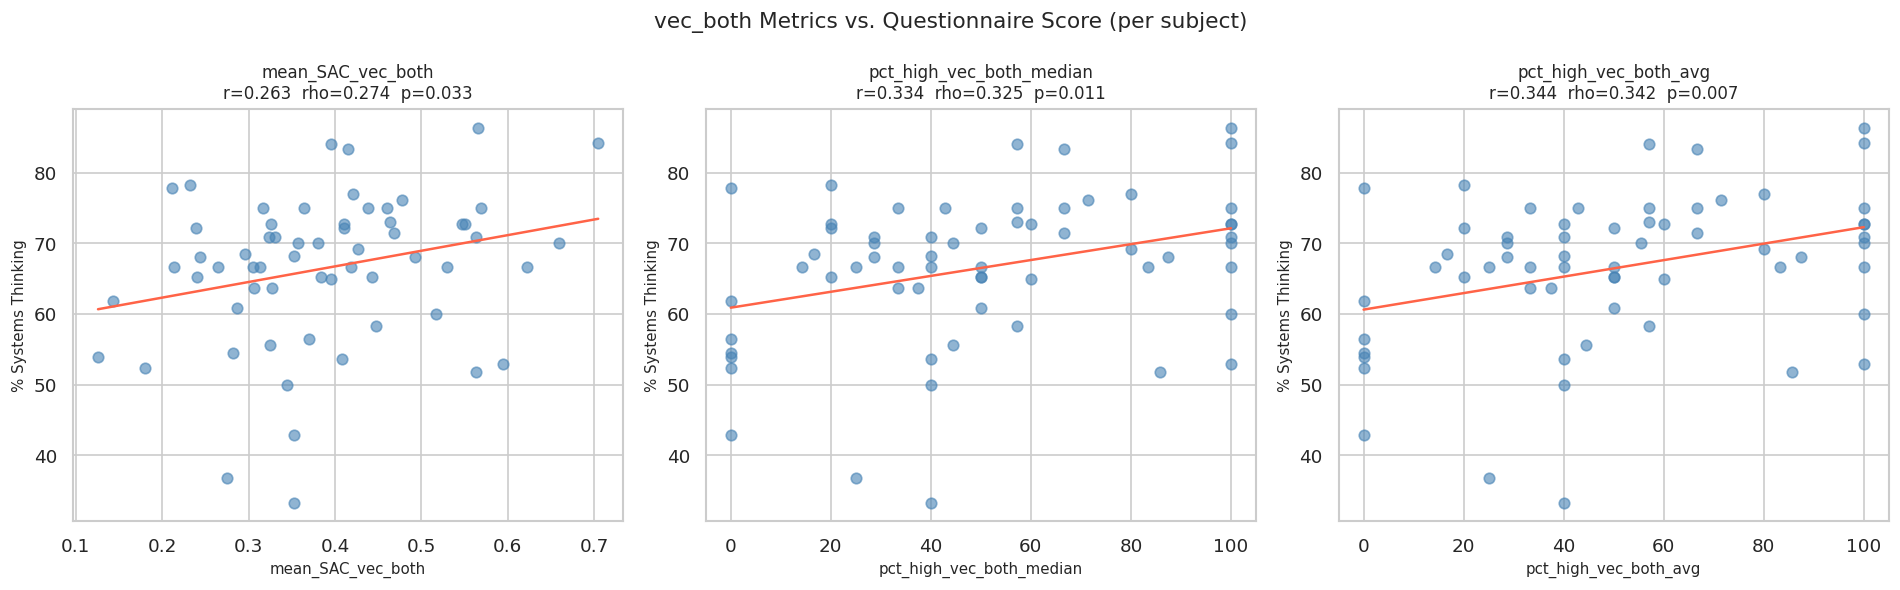

In [36]:
import pathlib

# -- Load questionnaire ---------------------------------------------------------
qt_path = pathlib.Path("questionnaire_1.csv")
if not qt_path.exists():
    raise FileNotFoundError(f"questionnaire_1.csv not found in {pathlib.Path.cwd()}")

qt = pd.read_csv(qt_path, index_col=0)
qt.index = qt.index.str.strip()
qt.columns = ["pct_systems_thinking"]
qt["subject_id"] = qt.index.str.extract(r"(\d+)", expand=False).astype(int)
qt = qt.reset_index(drop=True)
print(f"Questionnaire loaded: {len(qt)} subjects  "
      f"(range {qt['pct_systems_thinking'].min():.1f}% - {qt['pct_systems_thinking'].max():.1f}%)")

# -- Extract subject ID from stem ----------------------------------------------
df["subject_id"] = df["stem"].str.split("_").str[-1].astype(int)

# -- Thresholds for vec_both grounding -----------------------------------------
vec_both_med_thr = float(df["sim_above_concept_vec_both"].median())
vec_both_avg_thr = float(df["sim_above_concept_vec_both"].mean())
print(
    f"Grounding thresholds: vec_both >= median {vec_both_med_thr:.4f}, "
    f"vec_both >= mean {vec_both_avg_thr:.4f}"
)

# -- Per-subject aggregation (requested metrics) -------------------------------
per_subject = (
    df.groupby("subject_id")
    .agg(
        n                        = ("sim_above_concept_vec_both", "count"),
        mean_SAC_vec_both        = ("sim_above_concept_vec_both", "mean"),
        pct_high_vec_both_median = ("sim_above_concept_vec_both", lambda x: (x >= vec_both_med_thr).mean() * 100),
        pct_high_vec_both_avg    = ("sim_above_concept_vec_both", lambda x: (x >= vec_both_avg_thr).mean() * 100),
    )
    .round(4)
    .reset_index()
)
print(f"Pipeline subjects: {len(per_subject)}  |  Questionnaire subjects: {len(qt)}")

# -- Merge ---------------------------------------------------------------------
merged = per_subject.merge(qt, on="subject_id", how="inner")
print(f"Matched: {len(merged)} subjects after join\n")

# -- Full subject table sorted by questionnaire score --------------------------
display_merged = merged.sort_values("pct_systems_thinking", ascending=False).reset_index(drop=True)
display_merged.index += 1  # 1-based rank

display(display_merged.style
        .background_gradient(subset=["pct_systems_thinking"], cmap="RdYlGn")
        .background_gradient(subset=["mean_SAC_vec_both"],       cmap="Purples")
        .background_gradient(subset=["pct_high_vec_both_median"], cmap="BuPu")
        .background_gradient(subset=["pct_high_vec_both_avg"],    cmap="GnBu")
        .format({
            "pct_systems_thinking":    "{:.1f}%",
            "mean_SAC_vec_both":       "{:.4f}",
            "pct_high_vec_both_median": "{:.1f}%",
            "pct_high_vec_both_avg":   "{:.1f}%",
        })
        .set_caption("All subjects sorted by questionnaire % Systems Thinking (descending)"))

# -- Correlation table ----------------------------------------------------------
pipeline_metrics = ["mean_SAC_vec_both", "pct_high_vec_both_median", "pct_high_vec_both_avg"]

corr_rows = []
for pm in pipeline_metrics:
    sub = merged[[pm, "pct_systems_thinking"]].dropna()
    if len(sub) < 5:
        print(f"  skipping {pm}  (n={len(sub)})")
        continue
    r, p = stats.pearsonr(sub[pm], sub["pct_systems_thinking"])
    rho, p2 = stats.spearmanr(sub[pm], sub["pct_systems_thinking"])
    corr_rows.append({
        "pipeline_metric": pm,
        "pearson_r": round(r, 4),
        "pearson_p": round(p, 4),
        "spearman_rho": round(rho, 4),
        "spearman_p": round(p2, 4),
        "n": len(sub),
    })

corr_df = pd.DataFrame(corr_rows).sort_values("spearman_rho", ascending=False)
print("Correlation with % Systems Thinking (questionnaire_1.csv):")
display(corr_df.style
        .background_gradient(subset=["spearman_rho", "pearson_r"], cmap="RdYlGn", vmin=-1, vmax=1)
        .format("{:.4f}", subset=["pearson_r", "pearson_p", "spearman_rho", "spearman_p"]))

# -- Scatter plots --------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, pm in zip(axes.flat, pipeline_metrics):
    sub = merged[[pm, "pct_systems_thinking"]].dropna()
    ax.scatter(sub[pm], sub["pct_systems_thinking"], alpha=0.6, s=40, color="steelblue")
    if len(sub) > 5 and sub[pm].std() > 0:
        m, b = np.polyfit(sub[pm], sub["pct_systems_thinking"], 1)
        x_line = np.linspace(sub[pm].min(), sub[pm].max(), 100)
        ax.plot(x_line, m * x_line + b, color="tomato", linewidth=1.5)
        r, _ = stats.pearsonr(sub[pm], sub["pct_systems_thinking"])
        rho, p2 = stats.spearmanr(sub[pm], sub["pct_systems_thinking"])
        ax.set_title(f"{pm}\nr={r:.3f}  rho={rho:.3f}  p={p2:.3f}", fontsize=10)
    else:
        ax.set_title(pm, fontsize=10)
    ax.set_xlabel(pm, fontsize=9)
    ax.set_ylabel("% Systems Thinking", fontsize=9)

plt.suptitle("vec_both Metrics vs. Questionnaire Score (per subject)", fontsize=13)
plt.tight_layout()
plt.show()


## 14 · Correlations Within High Systems-Thinking Group (>= 65%)

This section restricts analysis to subjects with `pct_systems_thinking >= 65` and computes correlations among questionnaire score and all pipeline aggregate metrics.

Subjects with pct_systems_thinking >= 65%: 43 / 61


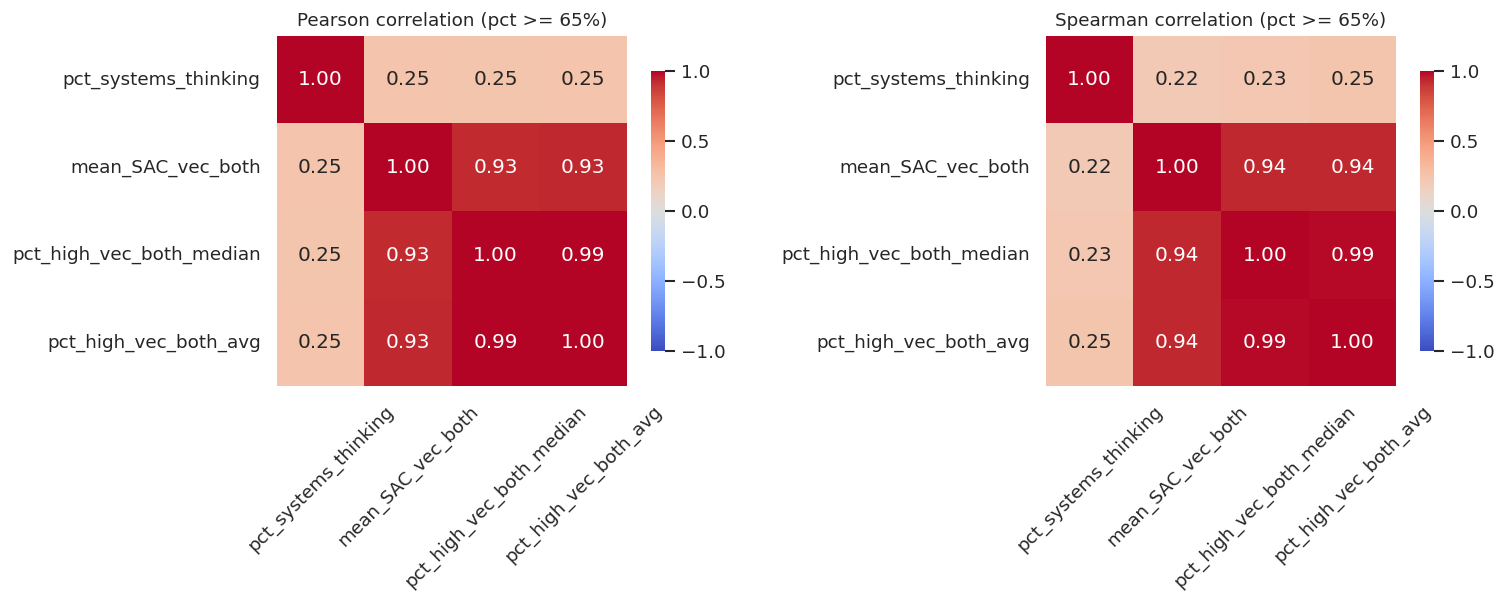


Correlations with questionnaire score inside high-score subgroup:


,metric,pearson_r,pearson_p,spearman_rho,spearman_p,n
2,pct_high_vec_both_avg,0.2517,0.1035,0.2458,0.1122,43
1,pct_high_vec_both_median,0.2485,0.1082,0.2266,0.1439,43
0,mean_SAC_vec_both,0.2516,0.1037,0.2184,0.1595,43


In [37]:
# Uses `merged` from Section 13
threshold = 65.0

high = merged.loc[merged["pct_systems_thinking"] >= threshold].copy()
print(f"Subjects with pct_systems_thinking >= {threshold:.0f}%: {len(high)} / {len(merged)}")

if len(high) < 5:
    print("Not enough subjects for stable correlation estimates.")
else:
    metric_cols = ["pct_systems_thinking", "mean_SAC_vec_both", "pct_high_vec_both_median", "pct_high_vec_both_avg"]
    metric_cols = [c for c in metric_cols if c in high.columns]

    # Correlations are undefined for constant columns; report and drop from heatmaps
    const_cols = [c for c in metric_cols if high[c].nunique(dropna=True) <= 1]
    metric_cols_corr = [c for c in metric_cols if c not in const_cols]
    if const_cols:
        print("Constant columns (excluded from heatmaps):", ", ".join(const_cols))

    pear = high[metric_cols_corr].corr(method="pearson")
    spear = high[metric_cols_corr].corr(method="spearman")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, corr, title in zip(axes, [pear, spear], ["Pearson", "Spearman"]):
        sns.heatmap(
            corr,
            ax=ax,
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            annot=True,
            fmt=".2f",
            square=True,
            cbar_kws={"shrink": 0.8},
        )
        ax.set_title(f"{title} correlation (pct >= {int(threshold)}%)", fontsize=11)
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", rotation=0)

    plt.tight_layout()
    plt.show()

    # Correlation of each pipeline metric with questionnaire score in high group
    rows = []
    target = "pct_systems_thinking"
    for col in metric_cols:
        if col == target:
            continue
        sub = high[[col, target]].dropna()
        if len(sub) < 5 or sub[col].std() == 0:
            continue
        r, p = stats.pearsonr(sub[col], sub[target])
        rho, p2 = stats.spearmanr(sub[col], sub[target])
        rows.append({
            "metric": col,
            "pearson_r": round(r, 4),
            "pearson_p": round(p, 4),
            "spearman_rho": round(rho, 4),
            "spearman_p": round(p2, 4),
            "n": len(sub),
        })

    corr_high = pd.DataFrame(rows).sort_values("spearman_rho", ascending=False)
    print("\nCorrelations with questionnaire score inside high-score subgroup:")
    display(
        corr_high.style
        .background_gradient(subset=["pearson_r", "spearman_rho"], cmap="RdYlGn", vmin=-1, vmax=1)
        .format("{:.4f}", subset=["pearson_r", "pearson_p", "spearman_rho", "spearman_p"])
    )

## 15 · Correlations Within Lower Systems-Thinking Group (< 65%)

This section restricts analysis to subjects with `pct_systems_thinking < 65` and computes correlations among questionnaire score and all pipeline aggregate metrics.

Subjects with pct_systems_thinking < 65%: 18 / 61


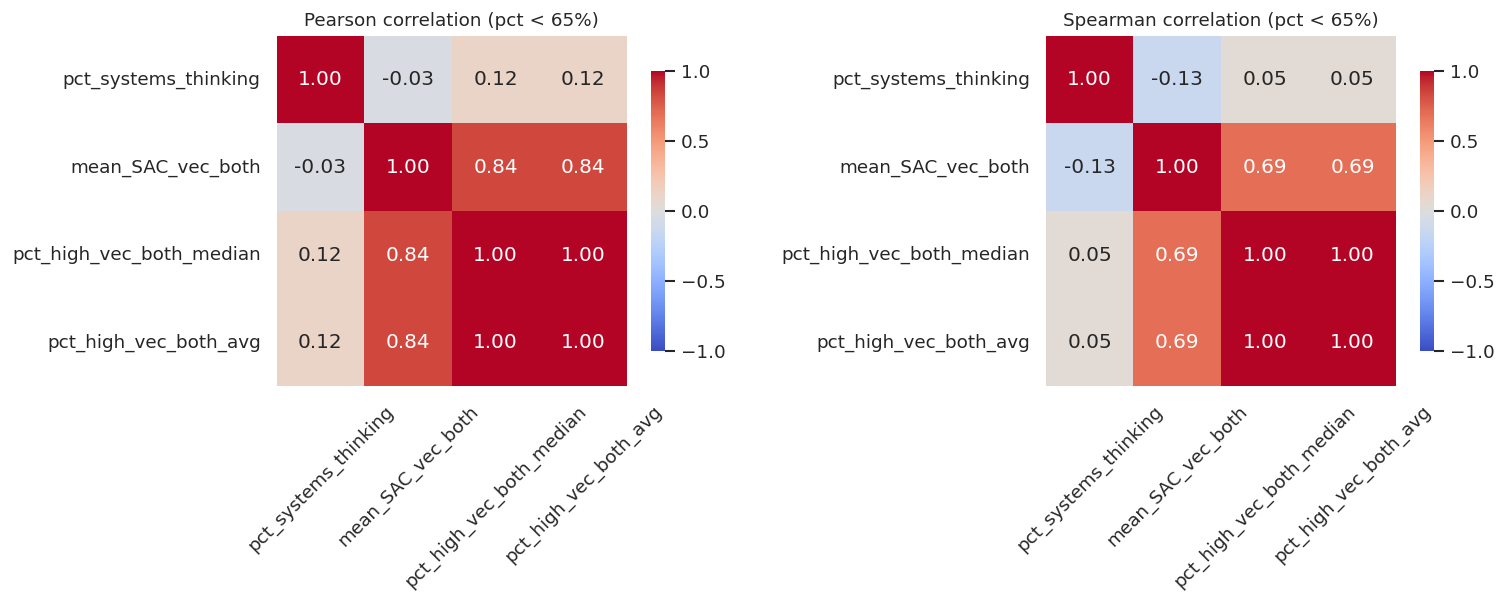


Correlations with questionnaire score inside lower-score subgroup:


,metric,pearson_r,pearson_p,spearman_rho,spearman_p,n
1,pct_high_vec_both_median,0.1150,0.6494,0.0453,0.8582,18
2,pct_high_vec_both_avg,0.1150,0.6494,0.0453,0.8582,18
0,mean_SAC_vec_both,-0.0315,0.9012,-0.1332,0.5983,18


In [38]:
# Uses `merged` from Section 13
threshold = 65.0

low = merged.loc[merged["pct_systems_thinking"] < threshold].copy()
print(f"Subjects with pct_systems_thinking < {threshold:.0f}%: {len(low)} / {len(merged)}")

if len(low) < 5:
    print("Not enough subjects for stable correlation estimates.")
else:
    metric_cols_low = ["pct_systems_thinking", "mean_SAC_vec_both", "pct_high_vec_both_median", "pct_high_vec_both_avg"]
    metric_cols_low = [c for c in metric_cols_low if c in low.columns]

    # Correlations are undefined for constant columns; report and drop from heatmaps
    const_cols_low = [c for c in metric_cols_low if low[c].nunique(dropna=True) <= 1]
    metric_cols_low_corr = [c for c in metric_cols_low if c not in const_cols_low]
    if const_cols_low:
        print("Constant columns (excluded from heatmaps):", ", ".join(const_cols_low))

    pear_low = low[metric_cols_low_corr].corr(method="pearson")
    spear_low = low[metric_cols_low_corr].corr(method="spearman")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, corr, title in zip(axes, [pear_low, spear_low], ["Pearson", "Spearman"]):
        sns.heatmap(
            corr,
            ax=ax,
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            annot=True,
            fmt=".2f",
            square=True,
            cbar_kws={"shrink": 0.8},
        )
        ax.set_title(f"{title} correlation (pct < {int(threshold)}%)", fontsize=11)
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", rotation=0)

    plt.tight_layout()
    plt.show()

    # Correlation of each pipeline metric with questionnaire score in low group
    rows_low = []
    target = "pct_systems_thinking"
    for col in metric_cols_low:
        if col == target:
            continue
        sub = low[[col, target]].dropna()
        if len(sub) < 5 or sub[col].std() == 0:
            continue
        r, p = stats.pearsonr(sub[col], sub[target])
        rho, p2 = stats.spearmanr(sub[col], sub[target])
        rows_low.append({
            "metric": col,
            "pearson_r": round(r, 4),
            "pearson_p": round(p, 4),
            "spearman_rho": round(rho, 4),
            "spearman_p": round(p2, 4),
            "n": len(sub),
        })

    corr_low = pd.DataFrame(rows_low).sort_values("spearman_rho", ascending=False)
    print("\nCorrelations with questionnaire score inside lower-score subgroup:")
    display(
        corr_low.style
        .background_gradient(subset=["pearson_r", "spearman_rho"], cmap="RdYlGn", vmin=-1, vmax=1)
        .format("{:.4f}", subset=["pearson_r", "pearson_p", "spearman_rho", "spearman_p"])
    )